# Spooky Author Identification — character language models and calibration

This notebook records improvements B and C using held-out predictions only. Improvement C adds a per-author, from-scratch character n-gram language model. Improvement B applies a multinomial logistic map to log-probabilities after pooling. Every reported validation probability is generated without using that sentence's label to fit pool exponents, language-model temperature, or calibration map.

The competition metric is multiclass log loss, so probability quality matters even where the predicted author is unchanged.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import spooky_common as S

sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
os.makedirs('assets', exist_ok=True); os.makedirs('submissions', exist_ok=True)
train, test, folds, y = S.load(); A = S.AUTHORS
meta_char = json.load(open('results/meta_charlm.json'))
meta = json.load(open('results/improvement_bc.json'))
z = np.load('results/improvement_bc.npz')
oof = {key[4:]: z[key] for key in z.files if key.startswith('oof_')}
test_p = {key[5:]: z[key] for key in z.files if key.startswith('test_')}
pd.DataFrame(meta).T[['log_loss', 'accuracy', 'macro_f1', 'ci95']].round(4)

,log_loss,accuracy,macro_f1,ci95
pool2,0.269314,0.895807,0.896048,"[0.2605365421633475, 0.27905531313636417]"
pool2_dir,0.267592,0.895909,0.896339,"[0.2590399559142225, 0.27725693306316057]"
pool3,0.337338,0.871852,0.871767,"[0.3280118986597836, 0.34750801900137973]"
pool3_dir,0.335217,0.874304,0.874463,"[0.3256501195225364, 0.3452260031061845]"
pool4,0.266051,0.896522,0.896707,"[0.25755298915542485, 0.27530453711158975]"
pool4_dir,0.264377,0.898105,0.898444,"[0.2559075459533654, 0.27363669376818683]"


## 1. Character language-model order

For each author and fold, a Witten–Bell interpolated character n-gram language model is fitted on the other four folds. Its three author log-likelihoods become probabilities after a temperature (`beta`) fitted on those same other folds. The order is chosen by its nested out-of-fold log loss.

,order,log_loss,accuracy,raw_log_loss,mean_beta
0,1,0.9270,0.5571,0.9401,0.7317
1,2,0.7393,0.6801,0.8879,0.4451
2,3,0.5294,0.7845,0.8663,0.2999
3,4,0.4148,0.8390,0.9512,0.2076
4,5,0.3945,0.8479,1.1518,0.1570
5,6,0.3882,0.8478,1.4012,0.1257
6,7,0.3804,0.8479,1.5945,0.1080
7,8,0.3785,0.8475,1.7612,0.0973
8,9,0.3784,0.8487,1.8635,0.0916


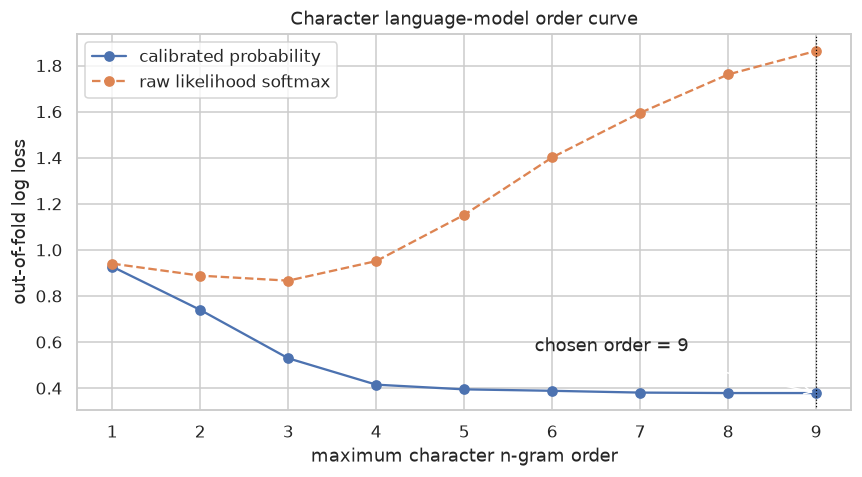

chosen order 9: log loss 0.3784, accuracy 0.8487; beta fitted on all OOF rows = 0.092


In [2]:
order = pd.DataFrame(meta_char['order_table'])
display(order[['order', 'log_loss', 'accuracy', 'raw_log_loss', 'mean_beta']].round(4))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(order.order, order.log_loss, 'o-', label='calibrated probability')
ax.plot(order.order, order.raw_log_loss, 'o--', label='raw likelihood softmax')
best = int(meta_char['order']); ax.axvline(best, color='black', lw=.8, ls=':')
ax.annotate(f'chosen order = {best}', (best, order.loc[order.order.eq(best), 'log_loss'].iloc[0]), xytext=(best-3.2, .56), arrowprops={'arrowstyle': '->'})
ax.set(xlabel='maximum character n-gram order', ylabel='out-of-fold log loss', title='Character language-model order curve')
ax.legend(); plt.tight_layout(); plt.savefig('assets/bc_01_charlm_order_curve.png', bbox_inches='tight'); plt.show()
print(f"chosen order {best}: log loss {meta_char['log_loss']:.4f}, accuracy {meta_char['accuracy']:.4f}; beta fitted on all OOF rows = {meta_char['beta_all_rows']:.3f}")

## 2. Complementarity: which member changes the pool

The character model is weaker by itself than NB-weighted logistic regression, but its errors are sufficiently different to improve the pool substantially. The comparison uses the same nested pooling procedure for every row.

,variant,log_loss,ci95,accuracy,macro_f1,exponents_all_rows
0,three legacy members,0.3373,"[0.3280118986597836, 0.34750801900137973]",0.8719,0.8718,"[0.8209043878577201, 0.1458499381466029, 0.171..."
1,NB-LR + character LM,0.2693,"[0.2605365421633475, 0.27905531313636417]",0.8958,0.8960,"[0.6614968231035163, 0.5928587665301159]"
2,four members,0.2661,"[0.25755298915542485, 0.27530453711158975]",0.8965,0.8967,"[0.5280746379195179, 0.14541412534560297, 0.11..."
3,four members + Dirichlet map,0.2644,"[0.2559075459533654, 0.27363669376818683]",0.8981,0.8984,"[0.5280746379195179, 0.14541412534560297, 0.11..."


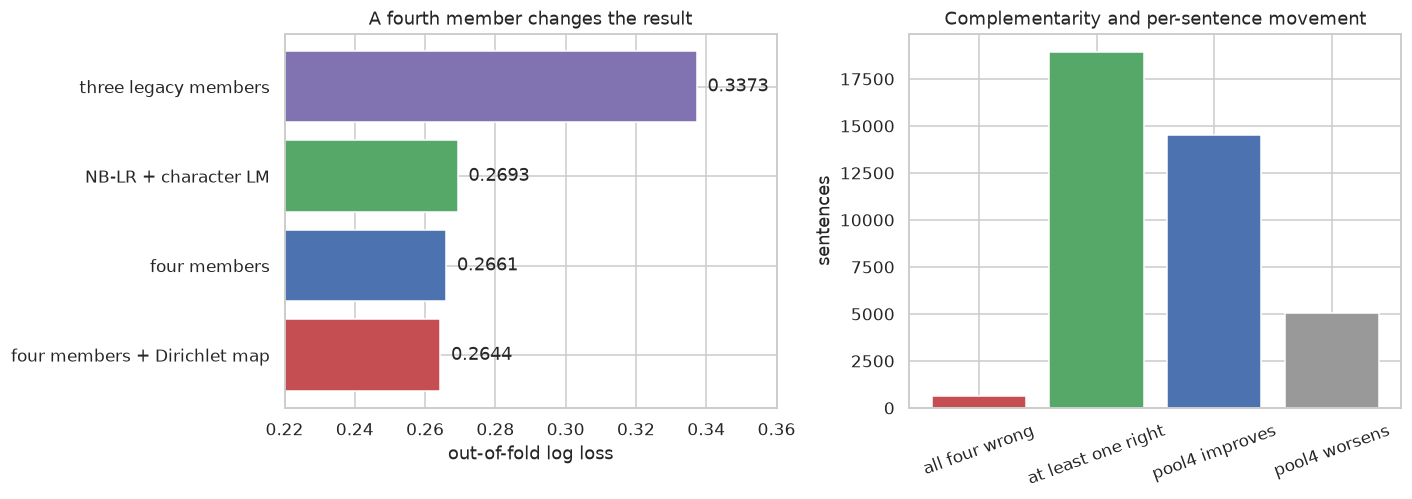

all four members are wrong on 3.2% of sentences; pool4's paired gain over pool3 is 0.0713 nats per sentence.


In [3]:
names = ['pool3', 'pool2', 'pool4', 'pool4_dir']
labels = ['three legacy members', 'NB-LR + character LM', 'four members', 'four members + Dirichlet map']
tab = pd.DataFrame([{'variant': label, **meta[name]} for name, label in zip(names, labels)])
display(tab[['variant', 'log_loss', 'ci95', 'accuracy', 'macro_f1', 'exponents_all_rows']].round(4))
base = oof['pool3']; p4 = oof['pool4']; pred = {name: p.argmax(1) != y for name, p in [('NB-LR', S.load_method('nblr')[0]), ('style GBDT', S.load_method('style_gbdt')[0]), ('CNN', S.load_method('cnn')[0]), ('character LM', S.load_method('charlm')[0])]}
all_wrong = np.logical_and.reduce(list(pred.values()))
gain = S.sample_loss(y, base) - S.sample_loss(y, p4)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].barh(labels[::-1], tab.log_loss.values[::-1], color=['#8172B2', '#55A868', '#4C72B0', '#C44E52'][::-1])
for i, v in enumerate(tab.log_loss.values[::-1]): axes[0].text(v+.003, i, f'{v:.4f}', va='center')
axes[0].set(xlim=(.22, .36), xlabel='out-of-fold log loss', title='A fourth member changes the result')
groups = pd.Series({'all four wrong': all_wrong.sum(), 'at least one right': (~all_wrong).sum(), 'pool4 improves': (gain > 1e-9).sum(), 'pool4 worsens': (gain < -1e-9).sum()})
axes[1].bar(groups.index, groups.values, color=['#C44E52', '#55A868', '#4C72B0', '#999999'])
axes[1].tick_params(axis='x', rotation=20); axes[1].set_ylabel('sentences'); axes[1].set_title('Complementarity and per-sentence movement')
plt.tight_layout(); plt.savefig('assets/bc_02_complementarity.png', bbox_inches='tight'); plt.show()
print(f"all four members are wrong on {all_wrong.mean():.1%} of sentences; pool4's paired gain over pool3 is {gain.mean():.4f} nats per sentence.")

## 3. What Dirichlet calibration changes

The final calibration map is fitted only after the pool has been created within each training partition. Its improvement is small, as expected for an already jointly calibrated pool, but it lowers log loss and slightly raises accuracy.

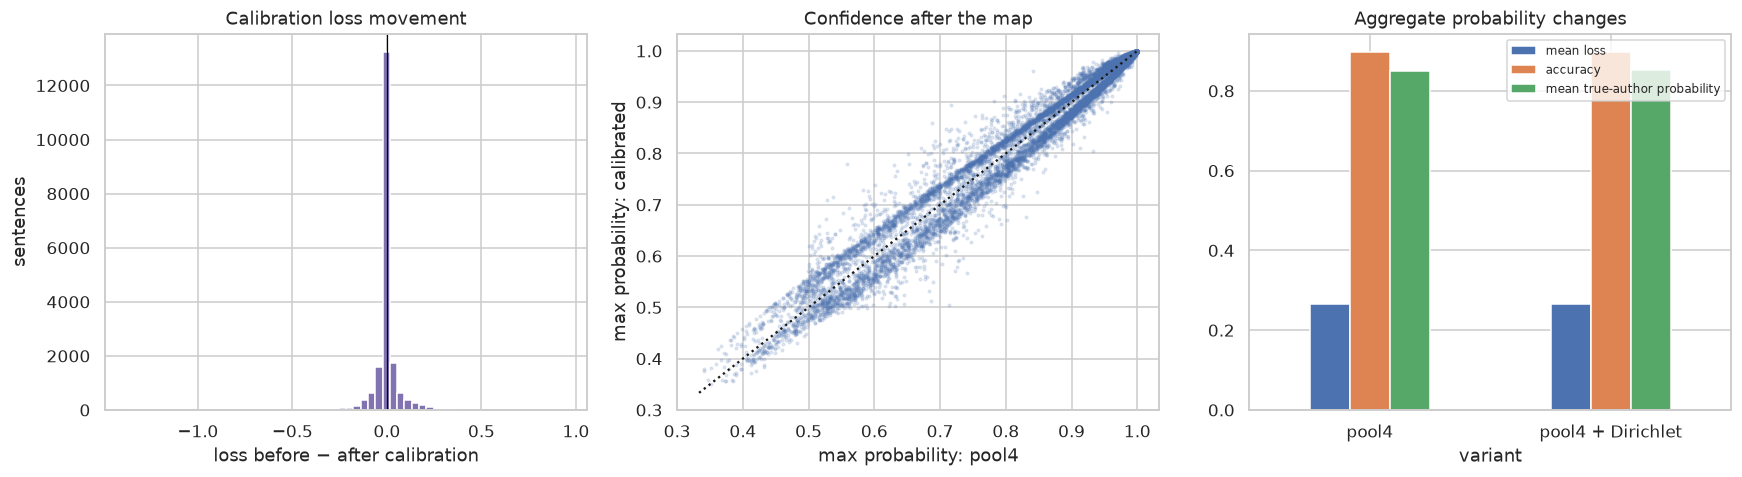

Dirichlet calibration changes log loss by -0.0017; it improves 54.6% of sentences.


In [4]:
before, after = oof['pool4'], oof['pool4_dir']
lb, la = S.sample_loss(y, before), S.sample_loss(y, after)
conf_b, conf_a = before.max(1), after.max(1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(lb-la, bins=60, color='#8172B2'); axes[0].axvline(0, color='black', lw=.8); axes[0].set(xlabel='loss before − after calibration', ylabel='sentences', title='Calibration loss movement')
axes[1].scatter(conf_b, conf_a, s=3, alpha=.15); axes[1].plot([1/3, 1], [1/3, 1], 'k:'); axes[1].set(xlabel='max probability: pool4', ylabel='max probability: calibrated', title='Confidence after the map')
rows = []
for p, name in [(before, 'pool4'), (after, 'pool4 + Dirichlet')]:
    rows.append({'variant': name, 'mean loss': S.sample_loss(y,p).mean(), 'accuracy': (p.argmax(1)==y).mean(), 'mean true-author probability': p[np.arange(len(y)),y].mean()})
pd.DataFrame(rows).set_index('variant').plot.bar(ax=axes[2], rot=0, title='Aggregate probability changes')
axes[2].legend(fontsize=8); plt.tight_layout(); plt.savefig('assets/bc_03_loss_decomposition.png', bbox_inches='tight'); plt.show()
print(f"Dirichlet calibration changes log loss by {(la.mean()-lb.mean()):+.4f}; it improves {(la < lb).mean():.1%} of sentences.")

## 4. Test predictions

The submission files contain `id`, `EAP`, `HPL`, and `MWS`. They are generated from the saved test probabilities; they have not been submitted to Kaggle.

In [5]:
sample = pd.read_csv('data/sample_submission.csv')
for name, p in [('pool4', test_p['pool4']), ('pool4_dir', test_p['pool4_dir'])]:
    sub = pd.DataFrame(S.clip_norm(p), columns=A); sub.insert(0, 'id', test.id.values)
    assert sub.shape == sample.shape and list(sub.columns) == list(sample.columns) and np.allclose(sub[A].sum(axis=1), 1)
    path = f'submissions/submission_{name}.csv'; sub.to_csv(path, index=False)
    print(path, sub.shape, sub[A].mean().round(4).to_dict())

submissions/submission_pool4.csv (8392, 4) {'EAP': 0.4141, 'HPL': 0.2832, 'MWS': 0.3027}
submissions/submission_pool4_dir.csv (8392, 4) {'EAP': 0.4014, 'HPL': 0.2859, 'MWS': 0.3127}
